__“Oil Price Prediction and Spike Analysis During the 2026 Iran War Using Machine Learning”__

In [22]:
# 1. IMPORT LIBRARIES

import pandas as pd                                     # for data handling (DataFrame)
import numpy as np                                      # for numerical operations

import matplotlib.pyplot as plt                         # for plotting graphs
import seaborn as sns                                   # for better visualization

# Model building and preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

# Metrics for evaluation
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Handling imbalanced data
from imblearn.over_sampling import SMOTE

# Clustering and PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

# Model saving
import pickle


In [24]:
# 2. LOAD DATASETS

oil = pd.read_csv("iran_war_oil_prices_daily_2026.csv")
gas = pd.read_csv("iran_war_gas_prices_by_state.csv")
events = pd.read_csv("iran_war_key_events_timeline.csv")

# Preview data (understand structure)
oil.head().T

,0,1,2,3,4
date,2026-02-09,2026-02-10,2026-02-14,2026-02-18,2026-02-24
brent_usd_barrel,67.4,69.3,71.2,72.8,71.5
wti_usd_barrel,62.1,64.2,65.8,67.4,66.2
dubai_usd_barrel,66.8,68.4,70.1,71.8,70.4
us_gas_avg_gallon,2.81,2.83,2.84,2.85,2.87
us_diesel_avg_gallon,3.68,3.7,3.71,3.72,3.74
strait_hormuz_daily_ships,138,138,138,138,138
iran_production_mbpd,3.3,3.3,3.3,3.3,3.2
key_event,Trump-Iran diplomatic talks described as 'very...,US warns ships to avoid Iranian waters during ...,Iran insists on maintaining uranium enrichment,US-Israel joint military exercises escalate te...,Final diplomatic ultimatum issued to Iran
war_day,-19,-18,-14,-10,-4


In [26]:
# 3. DATA PREPROCESSING

# Convert date column to datetime (important for time-based analysis)
oil['date'] = pd.to_datetime(oil['date'])

# Target variable (what we want to predict)
y = oil['brent_usd_barrel']

# Feature selection (important columns affecting price)
features = [
    'wti_usd_barrel',               # West Texas Intermediate oil price (another major oil benchmark (like brent), price of oil in us market
    'dubai_usd_barrel',             # oil price from Dubai
    'us_gas_avg_gallon',            # average petrol price in USA
    'strait_hormuz_daily_ships',    # Number of Ships passing through Strait of Hormuz
    'iran_production_mbpd',         # Oil production of Iran (million barrels per day)
    'war_day'                       # Number of days relative to war
]

X = oil[features]


In [28]:
# Check missing values
print(X.isnull().sum())

# Apply imputation only if missing values exist
if X.isnull().sum().sum() > 0:
    
    imputer = SimpleImputer(strategy='mean')
    X = imputer.fit_transform(X)

    print("Missing values handled")

else:
    print("No missing values found")

wti_usd_barrel               0
dubai_usd_barrel             0
us_gas_avg_gallon            0
strait_hormuz_daily_ships    0
iran_production_mbpd         0
war_day                      0
dtype: int64
No missing values found


In [30]:
# Check outliers using IQR

Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = y[(y < lower_bound) | (y > upper_bound)]

print("Number of outliers:", len(outliers))

Number of outliers: 0


In [32]:
# 6. FEATURE ENGINEERING
# Feature engineering for time-series forecasting
# Previous oil prices help predict future prices

# Add lag feature (previous day's price)
X['lag_price'] = y.shift(1)

# Add rolling mean (smooth trend)
X['rolling_mean'] = y.rolling(window=3).mean()       # Takes average of last 3 days

# Remove NaN values created by shift/rolling
X = X.dropna()
y = y[X.index]


In [54]:
# 8. TRAIN-TEST SPLIT

# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [58]:
# 7. FEATURE SCALING
# Standardization (important for ML models like KNN, SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [60]:
# 9. REGRESSION MODEL (MAIN MODEL)

# Linear Regression model
lr = LinearRegression()

# Train model
lr.fit(X_train, y_train)

# Predict on test data
y_pred = lr.predict(X_test)

In [62]:
# Print predictions

print(y_pred[:5])

[101.26095004 105.3454036  108.84268319 111.72680192 113.54942056]


In [64]:
# Compare actual vs predicted

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head())

   Actual   Predicted
0  100.80  101.260950
1  104.60  105.345404
2  108.65  108.842683
3  108.65  111.726802
4  110.30  113.549421


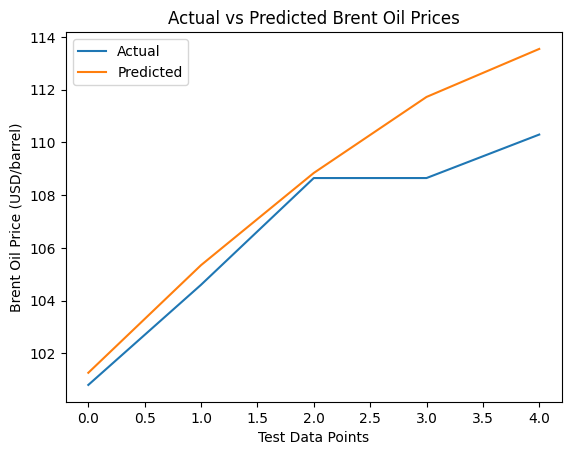

In [66]:
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.xlabel("Test Data Points")
plt.ylabel("Brent Oil Price (USD/barrel)")

plt.legend()
plt.title("Actual vs Predicted Brent Oil Prices")

plt.show()

In [68]:
# 10. REGRESSION EVALUATION

print("R2 Score:", r2_score(y_test, y_pred))  # Model fits data very well
print("MSE:", mean_squared_error(y_test, y_pred))  # error squared
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))  # interpretable error
print("MAE:", mean_absolute_error(y_test, y_pred))  # average error

R2 Score: 0.6512819577777629
MSE: 4.166134450429072
RMSE: 2.041111082334588
MAE: 1.545051859319301


In [72]:
# 11. REGULARIZATION (IMPROVEMENT)

# Ridge (reduces overfitting using L2 regularization)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# Lasso (feature selection + regularization)
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [74]:
#generate predictions:
ridge_pred = ridge.predict(X_test)
lasso_pred = lasso.predict(X_test)

In [76]:
#Compare with actual values
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Ridge_Predicted": ridge_pred,
    "Lasso_Predicted": lasso_pred
})

print(comparison.head())

   Actual  Ridge_Predicted  Lasso_Predicted
0  100.80       101.934635       100.872393
1  104.60       103.819271       104.594612
2  108.65       106.122983       108.104877
3  108.65       108.080671       111.028457
4  110.30       108.916629       112.702203


In [78]:
from sklearn.metrics import r2_score, mean_squared_error

print("Ridge R2:", r2_score(y_test, ridge_pred))
print("Lasso R2:", r2_score(y_test, lasso_pred))

print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("Lasso RMSE:", np.sqrt(mean_squared_error(y_test, lasso_pred)))

Ridge R2: 0.8238788395054037
Lasso R2: 0.8036315798434644
Ridge RMSE: 1.4505583423044193
Lasso RMSE: 1.5316701719398123


In [111]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(random_state=42)

rf_reg.fit(X_train, y_train)

rf_pred = rf_reg.predict(X_test)

print("Random Forest R2:", r2_score(y_test, rf_pred))

print("Random Forest RMSE:",
      np.sqrt(mean_squared_error(y_test, rf_pred)))

Random Forest R2: -1.9587339958148573
Random Forest RMSE: 5.945417987660763


In [105]:
print(rf_pred[:5])

[101.196  102.374  102.31   102.31   100.7482]


In [107]:
comparison_rf = pd.DataFrame({
    "Actual": y_test.values,
    "RF_Predicted": rf_pred
})

print(comparison_rf.head())

   Actual  RF_Predicted
0  100.80      101.1960
1  104.60      102.3740
2  108.65      102.3100
3  108.65      102.3100
4  110.30      100.7482


 __Secondary Objective - Detect oil price spikes using classification__

In [81]:
# 12. CLASSIFICATION PROBLEM

# Create binary target (price spike or not)
oil['spike'] = (oil['brent_usd_barrel'] > oil['brent_usd_barrel'].mean()).astype(int)

X_cls = oil[features]
y_cls = oil['spike']


In [83]:
# “Spike = sudden increase in price.”
print(oil[['brent_usd_barrel', 'spike']].head())

   brent_usd_barrel  spike
0              67.4      0
1              69.3      0
2              71.2      0
3              72.8      0
4              71.5      0


In [85]:
print(oil['spike'].value_counts())

spike
1    15
0     9
Name: count, dtype: int64


In [87]:
# 13. HANDLE IMBALANCED DATA

# Split data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2
)

# Apply SMOTE to balance dataset
smote = SMOTE()
X_train_c, y_train_c = smote.fit_resample(X_train_c, y_train_c)

In [88]:
print(y_train_c.value_counts())      #“SMOTE balances data by creating fake minority samples.”

spike
0    11
1    11
Name: count, dtype: int64


In [91]:
# 14. CLASSIFICATION MODEL

# Random Forest (best classification model)
rf = RandomForestClassifier()

# Train
rf.fit(X_train_c, y_train_c)

# Predict
y_pred_c = rf.predict(X_test_c)

print(y_pred_c[:5])

[0 1 1 1 0]


In [93]:
# Model is saying “All these cases will have high oil prices (above average)”

In [95]:
# 15. CLASSIFICATION EVALUATION

print("Accuracy:", accuracy_score(y_test_c, y_pred_c))
print("Precision:", precision_score(y_test_c, y_pred_c))
print("Recall:", recall_score(y_test_c, y_pred_c))
print("F1 Score:", f1_score(y_test_c, y_pred_c))

Accuracy: 0.8
Precision: 1.0
Recall: 0.75
F1 Score: 0.8571428571428571


In [97]:
# 16. CLUSTERING

# KMeans clustering (group similar patterns)
kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(X_scaled)

In [99]:
print(clusters[:5])         # 0 - low price , 1 - medium change , 2 - high price (spike)

[1 1 1 1 2]


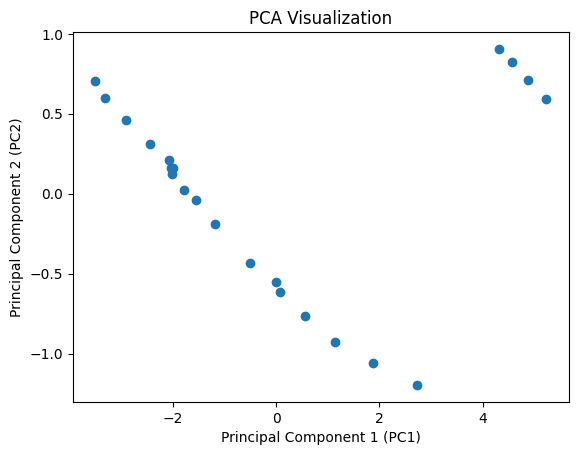

In [30]:
# 17. PCA (DIMENSION REDUCTION)

# Reduce features to 2 for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot PCA
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA Visualization")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.show()

In [31]:
# 18. CROSS VALIDATION

# Check model stability
cv_score = cross_val_score(lr, X_scaled, y, cv=5)
print("Cross Validation Score:", cv_score.mean())

Cross Validation Score: -15.286954042953147


In [32]:
# -15 is negative error , by defalut regression uses negative MSE

In [33]:
# 19. HYPERPARAMETER TUNING

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)   # 3 fold cross validation
grid.fit(X_train_c, y_train_c)

print("Best Parameters:", grid.best_params_)


Best Parameters: {'max_depth': 3, 'n_estimators': 50}


In [34]:
# 20. BIAS-VARIANCE CHECK    checks whether the model is learning properly or overfitiing

print("Train Score:", lr.score(X_train, y_train))        # how well model performs on training data
print("Test Score:", lr.score(X_test, y_test))           # testing data

Train Score: 0.9989963967727066
Test Score: 0.9862687646866358


In [35]:
# 21. SAVE MODEL

# Save trained model for deployment
pickle.dump(lr, open("model.pkl", "wb"))

In [36]:
import pickle
pickle.dump(lr, open('model.pkl', 'wb'))